In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Fraud_Analysis_Dataset.csv')
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [3]:
#EDA
df.shape

(11142, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [6]:
pd.set_option('display.float_format','{:.2f}'.format)

In [7]:
#statistics
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.00,11142.00,11142.00,11142.00,11142.00,11142.00,11142.00
mean,8.72,213191.49,924117.26,824957.65,888354.08,1103211.48,0.10
std,16.07,760065.01,2143004.31,2089894.17,2601375.85,2982447.12,0.30
min,1.00,2.39,0.00,0.00,0.00,0.00,0.00
25%,2.00,4946.62,427.00,0.00,0.00,0.00,0.00
50%,6.00,16761.26,28169.50,4420.60,0.00,0.00,0.00
75%,7.00,154336.58,304085.48,111412.64,271155.47,318637.36,0.00
max,95.00,10000000.00,19900000.00,13000000.00,33000000.00,34600000.00,1.00


In [8]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0   89.75
1   10.25
Name: proportion, dtype: float64

<Axes: xlabel='type', ylabel='count'>

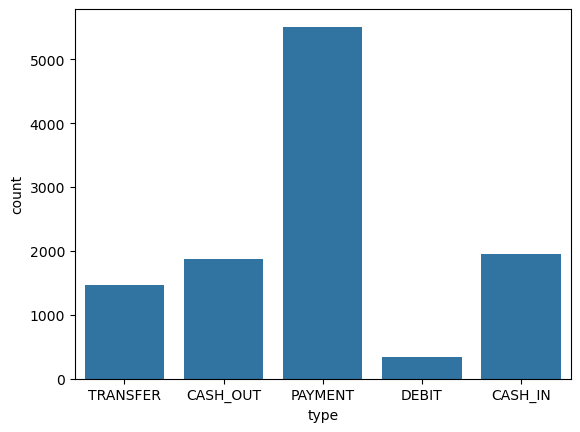

In [9]:
import seaborn as sns
sns.countplot(x='type',data=df)

<Axes: ylabel='amount'>

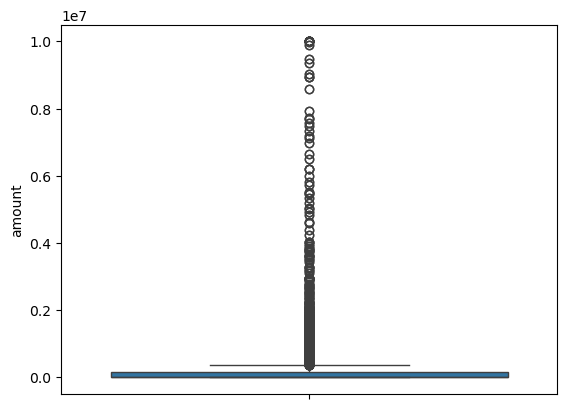

In [10]:
sns.boxplot(y=df['amount'])

In [11]:
df=df.drop(['nameOrig','nameDest','step'],axis=1)
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
2,TRANSFER,2806.00,2806.00,0.00,0.00,0.00,1
3,CASH_OUT,2806.00,2806.00,0.00,26202.00,0.00,1
4,TRANSFER,20128.00,20128.00,0.00,0.00,0.00,1


In [12]:
df=pd.get_dummies(df,drop_first=True,dtype='int')
df

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,181.00,0.00,0.00,0.00,1,0,0,0,1
1,181.00,181.00,0.00,21182.00,0.00,1,1,0,0,0
2,2806.00,2806.00,0.00,0.00,0.00,1,0,0,0,1
3,2806.00,2806.00,0.00,26202.00,0.00,1,1,0,0,0
4,20128.00,20128.00,0.00,0.00,0.00,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
11137,6393.71,433084.38,426690.68,478421.00,210535.25,0,0,1,0,0
11138,298799.54,426690.68,127891.14,704355.36,5270364.19,0,1,0,0,0
11139,423159.63,127891.14,0.00,610479.00,749621.53,0,1,0,0,0
11140,1094.03,13918.00,12823.97,0.00,0.00,0,0,0,1,0


In [13]:
x=df.drop('isFraud',axis=1)
y=df.isFraud

In [14]:
x

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,181.00,0.00,0.00,0.00,0,0,0,1
1,181.00,181.00,0.00,21182.00,0.00,1,0,0,0
2,2806.00,2806.00,0.00,0.00,0.00,0,0,0,1
3,2806.00,2806.00,0.00,26202.00,0.00,1,0,0,0
4,20128.00,20128.00,0.00,0.00,0.00,0,0,0,1
...,...,...,...,...,...,...,...,...,...
11137,6393.71,433084.38,426690.68,478421.00,210535.25,0,1,0,0
11138,298799.54,426690.68,127891.14,704355.36,5270364.19,1,0,0,0
11139,423159.63,127891.14,0.00,610479.00,749621.53,1,0,0,0
11140,1094.03,13918.00,12823.97,0.00,0.00,0,0,1,0


In [15]:
y

0        1
1        1
2        1
3        1
4        1
        ..
11137    0
11138    0
11139    0
11140    0
11141    0
Name: isFraud, Length: 11142, dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [17]:
x_scale=scaler.fit_transform(x)
x_scale

array([[-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       [-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27681175, -0.42993502, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       ...,
       [ 0.27626264, -0.37156334, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27906425, -0.42474954, -0.38861782, ..., -0.17902209,
         1.01101017, -0.38893563],
       [-0.26835212, -0.4125955 , -0.38005076, ..., -0.17902209,
         1.01101017, -0.38893563]])

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,random_state=70,test_size=0.3)

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [20]:
from imblearn.over_sampling import SMOTE

In [21]:
smt=SMOTE(random_state=42)
x_train_sm,y_train_sm=smt.fit_resample(x_train,y_train)

In [35]:
gb=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42,max_depth=5,min_samples_split=50,min_samples_leaf=50)

In [36]:
gb.fit(x_train_sm,y_train_sm)

GradientBoostingClassifier(max_depth=5, min_samples_leaf=50,
                           min_samples_split=50, random_state=42)

In [37]:
y_pred_tt=gb.predict(x_test)
y_pred_tr=gb.predict(x_train)

In [38]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,classification_report

In [39]:
acc_tt=accuracy_score(y_test,y_pred_tt)
print('acc_test',acc_tt)
acc_tr=accuracy_score(y_train,y_pred_tr)
print('acc train',acc_tr)

acc_test 0.9892312294346396
acc train 0.997179125528914


In [41]:
from sklearn.model_selection import GridSearchCV

In [47]:
grid_params={
    'learning_rate':[0.1,0.05,0.2,0.5],
    'max_depth':[6,8,10,20],
    'n_estimators':[10,15,50],
    'min_samples_split':[50,60,80,150],
    'min_samples_leaf':[50,120,200],
    
}
grid_para=GridSearchCV(gb,grid_params,cv=5,scoring='accuracy')
grid_para.fit(x_train_sm,y_train_sm)
print('the best parameter',grid_para.best_params_)
print('best score',grid_para.best_score_)

KeyboardInterrupt: 

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,uniform

In [53]:
grid_params={
    'learning_rate':uniform(0.1,1.9),
    'max_depth':randint(2,100),
    'n_estimators':[10,15,50],
    'min_samples_split':randint(10,100),
    'min_samples_leaf':randint(10,100)
    
}

In [54]:
rand=RandomizedSearchCV(
    estimator=gb,param_distributions=grid_params,cv=5,n_iter=10,n_jobs=-1,scoring='accuracy'
)
rand.fit(x_train_sm,y_train_sm)
print('best params',rand.best_params_)

best params {'learning_rate': np.float64(1.092627189514736), 'max_depth': 91, 'min_samples_leaf': 34, 'min_samples_split': 29, 'n_estimators': 15}


In [63]:
gb=GradientBoostingClassifier(n_estimators=10,learning_rate=0.5,random_state=42,max_depth=91,min_samples_split=29,min_samples_leaf=34)

In [64]:
gb.fit(x_train_sm,y_train_sm)

GradientBoostingClassifier(learning_rate=0.5, max_depth=91, min_samples_leaf=34,
                           min_samples_split=29, n_estimators=10,
                           random_state=42)

In [65]:
y_pred_tt=gb.predict(x_test)
y_pred_tr=gb.predict(x_train)

In [66]:
acc_tt=accuracy_score(y_test,y_pred_tt)
print('acc_test',acc_tt)
acc_tr=accuracy_score(y_train,y_pred_tr)
print('acc train',acc_tr)

acc_test 0.9913251570445707
acc train 0.9989742274650596


In [68]:
print(confusion_matrix(y_test, y_pred_tt))
print(classification_report(y_test, y_pred_tt))

[[2986   25]
 [   4  328]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3011
           1       0.93      0.99      0.96       332

    accuracy                           0.99      3343
   macro avg       0.96      0.99      0.98      3343
weighted avg       0.99      0.99      0.99      3343



In [69]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rand.best_estimator_, x_train_sm, y_train_sm, cv=5, scoring='accuracy')
print("Cross-validation mean accuracy:", scores.mean())

Cross-validation mean accuracy: 0.993847459058558


In [70]:
#feature importance
importance=gb.feature_importances_
feature_importance=pd.Series(importance,index=x.columns).sort_values(ascending=True)
sorted_importance = feature_importance.sort_values(ascending=False)

print("Feature Importance:")
print(sorted_importance)

Feature Importance:
newbalanceOrig   0.42
oldbalanceOrg    0.42
amount           0.09
type_PAYMENT     0.05
oldbalanceDest   0.01
newbalanceDest   0.00
type_CASH_OUT    0.00
type_DEBIT       0.00
type_TRANSFER    0.00
dtype: float64


In [71]:
importances = gb.feature_importances_
indices = np.argsort(importances)[::-1]

NameError: name 'gd' is not defined

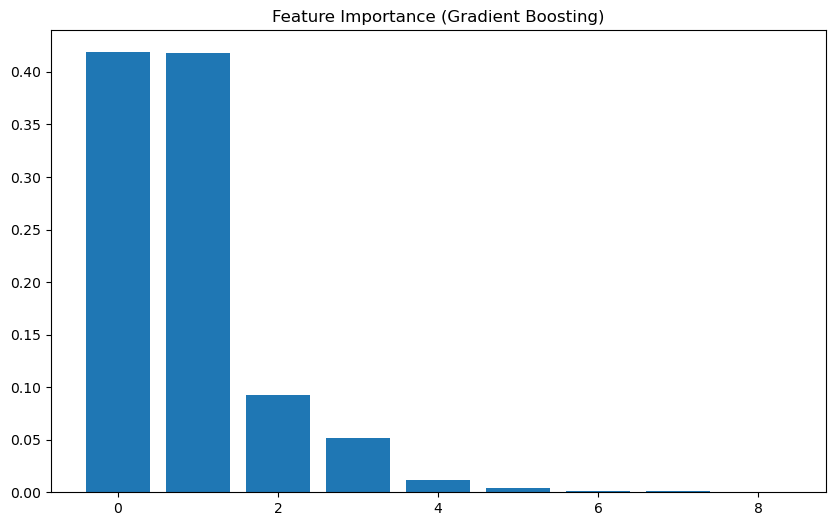

In [77]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.title("Feature Importance (Gradient Boosting)")
plt.bar(range(x.shape[1]), importances[indices])
plt.xticks(range(x.shape[1]), [gd.feature_names[i] for i in indices], rotation=90)
plt.show()

In [26]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
gds=GridSearchCV(
    param_grid=grid_params,
    estimator=ab,
    verbose=2,n_jobs=-1,
    scoring='accuracy',
    cv=cv
)

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform  # Import from scipy.stats, not random

params_dist = {
    'n_estimators': randint(50, 301),    # scipy.stats.randint (50 to 300 inclusive)
    'learning_rate': uniform(0.1, 1.9)   # scipy.stats.uniform (0.1 to 2.0)
}

random_search = RandomizedSearchCV(
    estimator=ab,
    param_distributions=params_dist,
    scoring='accuracy',
    random_state=42,
    n_iter=20,
    cv=cv
)

random_search.fit(x_train, y_train)

print('Best score:', random_search.best_score_)
print('Best params:', random_search.best_params_)

C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorith

Best score: 0.9944866860742423
Best params: {'learning_rate': np.float64(1.9681386830328975), 'n_estimators': 298}


In [38]:
#from random import randint,uniform
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')
params_dist={
    'n_estimators':randint(50,301),
    'learning_rate':uniform(0.1,1.9)
}
random_search=RandomizedSearchCV(
    param_distributions=params_dist,
    estimator=ab,
    scoring='accuracy',
    random_state=42,
    n_iter=20,
    #cv=cv
)
random_search.fit(x_train_sm,y_train_sm)

print('print the best score',random_search.best_score_)
print('print the params',random_search.best_params_)

print the best score 0.9944197563091665
print the params {'learning_rate': np.float64(1.4453378978124864), 'n_estimators': 199}


In [36]:
gds.fit(x_train_sm,y_train_sm)
print('best score',gds.best_score_)
print('best params',gds.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\Daniel\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


best score 0.9942767715699146
best params {'learning_rate': 1, 'n_estimators': 100}


In [ ]:
| Parameter             | How to choose a value               | Tips                                                                                                      |
| --------------------- | ----------------------------------- | --------------------------------------------------------------------------------------------------------- |
| `n_estimators`        | Number of trees                     | Start with 100–500. More trees → better learning but slower. Use **early stopping** to avoid overfitting. |
| `learning_rate`       | Shrink each tree’s contribution     | Start with 0.05–0.1. Smaller = more trees needed. Trade-off: small lr + many trees → better performance.  |
| `max_depth`           | Depth of each tree                  | 3–5 is usually enough. Deeper trees → can overfit.                                                        |
| `min_samples_split`   | Min samples to split a node         | 2–10. Higher → fewer splits → simpler tree → less overfit.                                                |
| `min_samples_leaf`    | Min samples in a leaf               | 1–10. Higher → smoother predictions.                                                                      |
| `max_features`        | Number of features per split        | 'sqrt', 'log2', or int. Lower → more randomness → less overfit.                                           |
| `subsample`           | Fraction of data per tree           | 0.7–1.0. Less than 1 → stochastic boosting → less overfit.                                                |
| `loss`                | Type of error to minimize           | Classification → 'log_loss', Regression → 'squared_error'                                                 |
| `validation_fraction` | Fraction of training for validation | 0.1–0.2. Small fraction enough for early stopping.                                                        |
| `n_iter_no_change`    | Early stopping patience             | 5–20. Stop training if no improvement in this many trees.                                                 |


In [40]:
y_pred_t=ab.predict(x_test)
y_pred_train=ab.predict(x_train)
print('test',y_pred_t)
print('train',y_pred_train)

test [0 1 0 ... 0 0 0]
train [0 0 1 ... 0 0 0]


In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report
tt_acc=accuracy_score(y_test,y_pred_t)
print('test',tt_acc)
tr_acc=accuracy_score(y_train,y_pred_train)
print('train',tr_acc)

test 0.9880346993718218
train 0.9992306705987947


In [42]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(ab, x_train, y_train, cv=5, scoring='accuracy')
print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.98974359 0.97435897 0.98269231 0.98974359 0.98652983]
Mean CV Accuracy: 0.9846136576701042


In [45]:
#feature importance
importance=ab.feature_importances_
feature_importance=pd.Series(importance,index=x.columns).sort_values(ascending=True)
sorted_importance = feature_importance.sort_values(ascending=False)

print("Feature Importance:")
print(sorted_importance)


Feature Importance:
oldbalanceOrg    0.25
amount           0.23
newbalanceDest   0.17
oldbalanceDest   0.12
newbalanceOrig   0.10
type_PAYMENT     0.05
type_CASH_OUT    0.05
type_TRANSFER    0.01
type_DEBIT       0.01
dtype: float64


In [46]:
#Permutation importance
from sklearn.inspection import permutation_importance
results=permutation_importance(ab,x_train,y_train,random_state=42,n_repeats=10)
importance_df = pd.DataFrame({
 'feature': x.columns,   # column names
    'importance_mean': results.importances_mean,
    'importance_std': results.importances_std
}).sort_values(by="importance_mean", ascending=False)

print(importance_df)
print("="*7)
print(results.importances_mean)

          feature  importance_mean  importance_std
2  newbalanceOrig             0.15            0.00
1   oldbalanceOrg             0.15            0.00
7    type_PAYMENT             0.07            0.00
0          amount             0.05            0.00
3  oldbalanceDest             0.05            0.00
5   type_CASH_OUT             0.01            0.00
4  newbalanceDest             0.01            0.00
8   type_TRANSFER             0.00            0.00
6      type_DEBIT             0.00            0.00
[4.73009360e-02 1.47775356e-01 1.50814207e-01 4.59930760e-02
 1.09244775e-02 1.09885883e-02 5.12886267e-05 7.33170919e-02
 5.25708424e-04]
